In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset(
    "zeroshot/twitter-financial-news-sentiment"
)

print(dataset)

README.md:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

C:\Users\SARITHA\PycharmProjects\financial_sentimental_analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SARITHA\.cache\huggingface\hub\datasets--zeroshot--twitter-financial-news-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sent_train.csv:   0%|          | 0.00/859k [00:00<?, ?B/s]

sent_valid.csv:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


In [2]:
# ============================================================
# STEP 2 - CONVERT DATASET TO PANDAS
# ============================================================

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()

print("\nTraining Data:")
print(train_df.head())

print("\nValidation Data:")
print(valid_df.head())

print("\nTraining Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nLabel Distribution:")
print(train_df["label"].value_counts())

print("\nMissing Values:")
print(train_df.isnull().sum())


Training Data:
                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0

Validation Data:
                                                text  label
0  $ALLY - Ally Financial pulls outlook https://t...      0
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0
2  $PRTY - Moody's turns negative on Party City h...      0
3                   $SAN: Deutsche Bank cuts to Hold      0
4                  $SITC: Compass Point cuts to Sell      0

Training Shape: (9543, 2)
Validation Shape: (2388, 2)

Columns:
Index(['text', 'label'], dtype='str')

Label Distribution:
label
2    6178
1    1923
0    1442
Name: count, dtype: int64

Missing Values:
text     0
label    0
dtype: int64


In [3]:
print(train_df["label"].unique())

[0 1 2]


In [4]:
print(train_df.groupby("label")["text"].count())

label
0    1442
1    1923
2    6178
Name: text, dtype: int64


In [5]:
# ============================================================
# STEP 3 - UNDERSTAND SENTIMENT LABELS
# ============================================================

for label in sorted(train_df["label"].unique()):
    print("\n" + "=" * 60)
    print("LABEL:", label)
    print("=" * 60)

    examples = train_df[train_df["label"] == label]["text"].head(10)

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


LABEL: 0
1. $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
2. $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
3. $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
4. $ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N
5. $FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB
6. $FTI - TechnipFMC downgraded at Berenberg but called Top Pick at Deutsche Bank https://t.co/XKcPDilIuU
7. $GM - GM loses a bull https://t.co/tdUfG5HbXy
8. $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
9. $GTT: Cowen cuts to Market Perform
10. $HNHAF $HNHPD $AAPL - Trendforce cuts iPhone estimate after Foxconn delay https://t.co/rlnEwzlzzS

LABEL: 1
1. $ALTG: Dougherty & Company starts at Buy
2. $AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX
3. $ANCUF: BMO Capital Markets ups to Outperform
4. $BHE: Lake Street starts at Buy
5


Sentiment Distribution:
sentiment
Neutral     6178
Positive    1923
Negative    1442
Name: count, dtype: int64


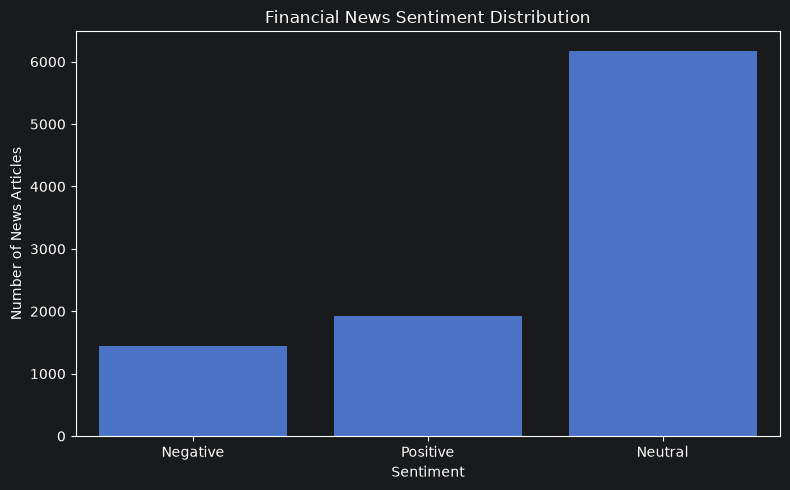


Text Length Statistics:
count    9543.000000
mean       85.816934
std        35.097229
min         2.000000
25%        58.000000
50%        79.000000
75%       120.000000
max       190.000000
Name: text_length, dtype: float64

Average Text Length by Sentiment:
sentiment
Negative    83.32
Neutral     88.09
Positive    80.38
Name: text_length, dtype: float64


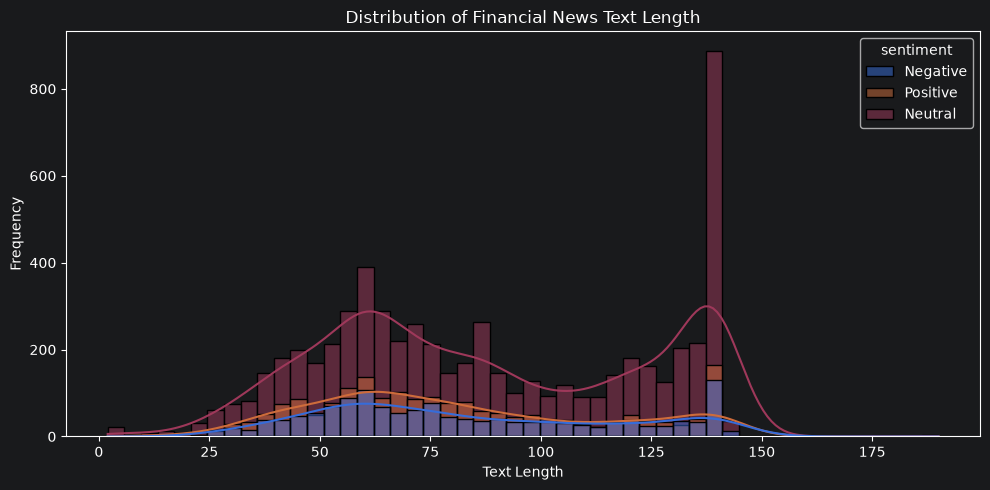

In [6]:
# ============================================================
# STEP 4 - EXPLORATORY DATA ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Sentiment Distribution
# ------------------------------------------------------------

label_names = {
    0: "Negative",
    1: "Positive",
    2: "Neutral"
}

train_df["sentiment"] = train_df["label"].map(label_names)

print("\nSentiment Distribution:")
print(train_df["sentiment"].value_counts())

# ------------------------------------------------------------
# 2. Plot Sentiment Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="sentiment",
    order=["Negative", "Positive", "Neutral"]
)

plt.title("Financial News Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of News Articles")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Calculate Text Length
# ------------------------------------------------------------

train_df["text_length"] = train_df["text"].str.len()

print("\nText Length Statistics:")
print(train_df["text_length"].describe())

# ------------------------------------------------------------
# 4. Text Length by Sentiment
# ------------------------------------------------------------

print("\nAverage Text Length by Sentiment:")
print(
    train_df.groupby("sentiment")["text_length"]
    .mean()
    .round(2)
)

# ------------------------------------------------------------
# 5. Text Length Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="text_length",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Distribution of Financial News Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 5 - TEXT PREPROCESSING
# ============================================================

import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove stock ticker symbols such as $aapl
    text = re.sub(r"\$[a-zA-Z]+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning
train_df["clean_text"] = train_df["text"].apply(clean_text)

valid_df["clean_text"] = valid_df["text"].apply(clean_text)


# Display original and cleaned text
print("\nOriginal vs Cleaned Text:")
print(train_df[["text", "clean_text"]].head(10))


# Check for empty text
print("\nEmpty cleaned training texts:",
      (train_df["clean_text"] == "").sum())

print("Empty cleaned validation texts:",
      (valid_df["clean_text"] == "").sum())


Original vs Cleaned Text:
                                                text  \
0  $BYND - JPMorgan reels in expectations on Beyo...   
1  $CCL $RCL - Nomura points to bookings weakness...   
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...   
3  $ESS: BTIG Research cuts to Neutral https://t....   
4  $FNKO - Funko slides after Piper Jaffray PT cu...   
5  $FTI - TechnipFMC downgraded at Berenberg but ...   
6      $GM - GM loses a bull https://t.co/tdUfG5HbXy   
7  $GM: Deutsche Bank cuts to Hold https://t.co/7...   
8                 $GTT: Cowen cuts to Market Perform   
9  $HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...   

                                          clean_text  
0      jpmorgan reels in expectations on beyond meat  
1  nomura points to bookings weakness at carnival...  
2  cemex cut at credit suisse j p morgan on weak ...  
3                      btig research cuts to neutral  
4            funko slides after piper jaffray pt cut  
5  technipfmc downgraded a

In [9]:
# Remove rows where cleaned text is empty
train_df = train_df[train_df["clean_text"].str.strip() != ""].copy()
valid_df = valid_df[valid_df["clean_text"].str.strip() != ""].copy()

print("\nAfter removing empty texts:")
print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("\nEmpty training texts:",
      (train_df["clean_text"] == "").sum())

print("Empty validation texts:",
      (valid_df["clean_text"] == "").sum())


After removing empty texts:
Training shape: (9529, 5)
Validation shape: (2385, 3)

Empty training texts: 0
Empty validation texts: 0


In [10]:
# ============================================================
# STEP 6 - TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training data
X_train = tfidf.fit_transform(train_df["clean_text"])

# Transform validation data
X_valid = tfidf.transform(valid_df["clean_text"])

# Target labels
y_train = train_df["label"]
y_valid = valid_df["label"]

print("\nTF-IDF Feature Information")
print("--------------------------------")

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_valid.shape)

print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])


TF-IDF Feature Information
--------------------------------
Training feature shape: (9529, 5000)
Validation feature shape: (2385, 5000)
Number of TF-IDF features: 5000

First 20 TF-IDF features:
['ab' 'ab publ' 'abbvie' 'about' 'about points' 'about the' 'about this'
 'about to' 'above' 'accelerated' 'accelerating' 'accept' 'accepts'
 'access' 'access to' 'acco' 'according' 'according to' 'account'
 'accounting']


In [11]:
X_train = tfidf.fit_transform(train_df["clean_text"])

In [12]:
X_valid = tfidf.transform(valid_df["clean_text"])

In [13]:
# ============================================================
# STEP 7 - TRAIN MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ------------------------------------------------------------
# 1. Create Models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        class_weight="balanced"
    )
}

# ------------------------------------------------------------
# 2. Train Models
# ------------------------------------------------------------

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    model.fit(X_train, y_train)

    trained_models[name] = model

    print("Training completed successfully.")

print("\nAll models trained successfully.")


Training: Logistic Regression
Training completed successfully.

Training: Naive Bayes
Training completed successfully.

Training: Linear SVM
Training completed successfully.

All models trained successfully.


In [14]:
class_weight="balanced"


MODEL: Logistic Regression
Accuracy : 0.7920
Precision: 0.8098
Recall   : 0.7920
F1 Score : 0.7982

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.72      0.63       347
    Positive       0.68      0.72      0.70       475
     Neutral       0.91      0.83      0.87      1563

    accuracy                           0.79      2385
   macro avg       0.71      0.76      0.73      2385
weighted avg       0.81      0.79      0.80      2385



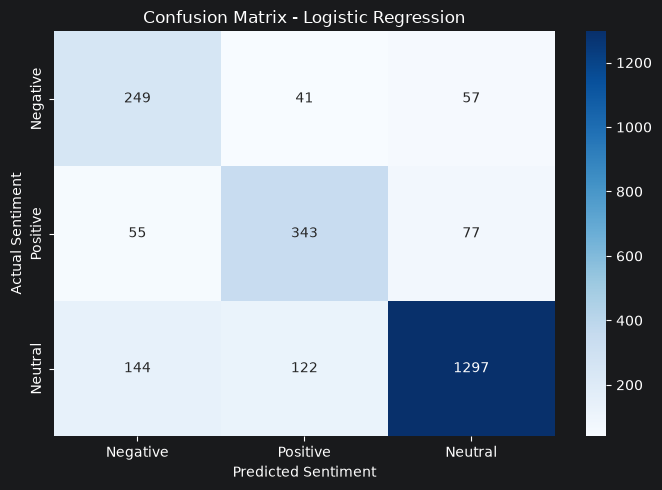


MODEL: Naive Bayes
Accuracy : 0.7908
Precision: 0.7957
Recall   : 0.7908
F1 Score : 0.7662

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.34      0.48       347
    Positive       0.77      0.53      0.63       475
     Neutral       0.79      0.97      0.87      1563

    accuracy                           0.79      2385
   macro avg       0.81      0.61      0.66      2385
weighted avg       0.80      0.79      0.77      2385



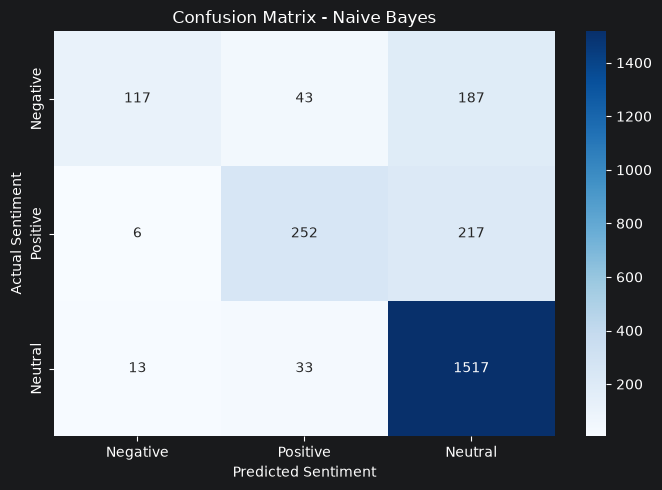


MODEL: Linear SVM
Accuracy : 0.8197
Precision: 0.8213
Recall   : 0.8197
F1 Score : 0.8205

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.67      0.66       347
    Positive       0.72      0.72      0.72       475
     Neutral       0.89      0.88      0.89      1563

    accuracy                           0.82      2385
   macro avg       0.75      0.76      0.76      2385
weighted avg       0.82      0.82      0.82      2385



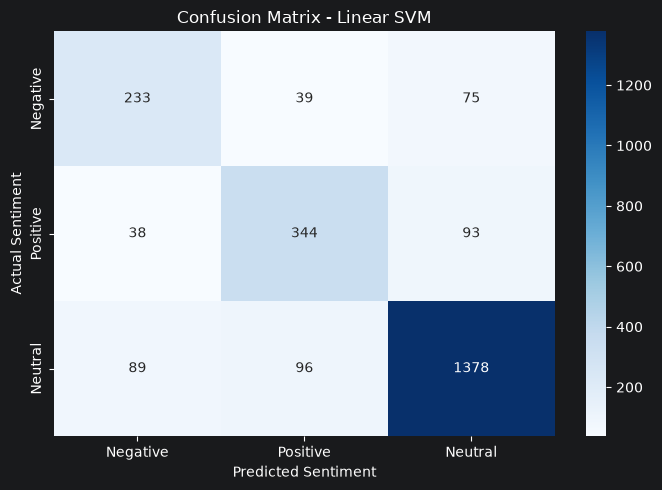


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
         Linear SVM  0.819706   0.821328 0.819706  0.820465
Logistic Regression  0.792034   0.809849 0.792034  0.798201
        Naive Bayes  0.790776   0.795703 0.790776  0.766190


In [15]:
# ============================================================
# STEP 8 - MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Store evaluation results
results = []

# Sentiment names
target_names = ["Negative", "Positive", "Neutral"]

for name, model in trained_models.items():

    print("\n" + "=" * 70)
    print("MODEL:", name)
    print("=" * 70)

    # Predictions
    y_pred = model.predict(X_valid)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)

    precision = precision_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Print metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_valid,
            y_pred,
            target_names=target_names,
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_valid, y_pred)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Sentiment")
    plt.tight_layout()
    plt.show()


# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).to_string(index=False)
)

In [16]:
# ============================================================
# STEP 9 - SAVE BEST MODEL AND TF-IDF VECTORIZER
# ============================================================

import joblib
import os

# ------------------------------------------------------------
# Create models folder
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# Get the best model
# ------------------------------------------------------------

best_model = trained_models["Linear SVM"]

# ------------------------------------------------------------
# Save Linear SVM model
# ------------------------------------------------------------

joblib.dump(
    best_model,
    "models/linear_svm_model.pkl"
)

# ------------------------------------------------------------
# Save TF-IDF vectorizer
# ------------------------------------------------------------

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

# ------------------------------------------------------------
# Save model comparison results
# ------------------------------------------------------------

results_df.to_csv(
    "models/model_comparison.csv",
    index=False
)

print("\n" + "=" * 60)
print("MODEL SAVING COMPLETED")
print("=" * 60)

print("\nSaved files:")

print("1. models/linear_svm_model.pkl")
print("2. models/tfidf_vectorizer.pkl")
print("3. models/model_comparison.csv")


MODEL SAVING COMPLETED

Saved files:
1. models/linear_svm_model.pkl
2. models/tfidf_vectorizer.pkl
3. models/model_comparison.csv
